In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
from matplotlib.collections import LineCollection
from src.results_paper import *
from src.TimeSeriesAnalysis import *
from src.process_data import run_processing_data
from IPython.display import clear_output

## 1 COLOR

In [2]:
savepath_TS_1_color = "../results/TimeSeries/2D"
create_folder(savepath_TS_1_color)

In [3]:
run_processing_data(base_root="../Data", force_recompute=False, burn_in=0.20, verbose=True)
clear_output()

## <b> FIGURE 1 </b>

$P_0 = 100$ (seeds)  
$p_0 = 1.0$ (initial probability)  
$L = 1000$  
$k = 10^{-5}$  
$N_T = 200$


In [4]:
L = 2048
k = 2.0e-04
Nt = 200
dim = 2
rho = 1.0
prop = "Pt"
num_colors = 1
type_perc = 'node'
filename = "P0_0.10_p0_0.40_seed_13970049.json"
path = f"../Data/{type_perc}_percolation/num_colors_{num_colors}/dim_{dim}/L_{L}/NT_constant/NT_{Nt}/k_{k:.1e}/rho_{rho:.4e}/data/"
path_json = path + filename

metas, df = load_bundle_old(path_json)
df

,order,t,pt,nt
0,1,0,0.4000,20.0
1,1,1,0.4370,15.0
2,1,2,0.4746,12.0
3,1,3,0.5120,13.0
4,1,4,0.5492,14.0
...,...,...,...,...
4913,1,4913,0.5560,176.0
4914,1,4914,0.5626,167.0
4915,1,4915,0.5654,186.0
4916,1,4916,0.5672,191.0


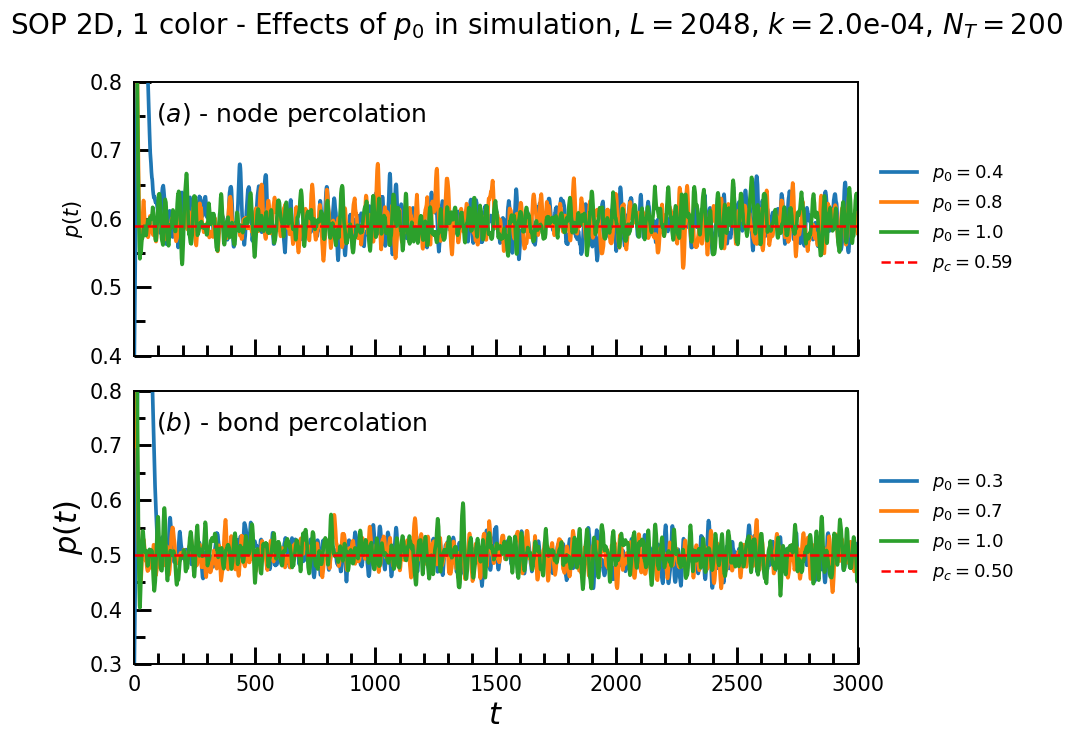

In [ ]:
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(10, 7), sharex=True)

L = 2048
k = 2.0e-04
Nt = 200
dim = 2
rho = 1.0
num_colors = 1

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
fontsize_ticks = 15
fontsize_legend = 13
fontsize_labels = 22
thickness = 1.4

p_0_node = [0.4, 0.8, 1.0]
seeds_name_node = [13970049, 336794095 , 655361741] #lab

p_0_bond = [0.3, 0.7, 1.0]
seeds_name_bond = [570876, 1661938458, 2141247169] #lab


colors = ['#1f77b4', '#ff7f0e', '#2ca02c', 'd62728']

for i in range(len(seeds_name_node)):
    path = f"../Data/node_percolation/num_colors_{num_colors}/dim_{dim}/L_{L}/NT_constant/NT_{Nt}/k_{k:.1e}/rho_{rho:.4e}/data/"
    metas, df = load_bundle_old(path + f"P0_0.10_p0_{p_0_node[i]:.2f}_seed_{seeds_name_node[i]}.json")
    axs[0].plot(df["t"], df["pt"], lw=1.9*thickness, label=f'$p_0 = {p_0_node[i]}$', color=colors[i])

for i in range(len(seeds_name_bond)):
    path = f"../Data/bond_percolation/num_colors_{num_colors}/dim_{dim}/L_{L}/NT_constant/NT_{Nt}/k_{k:.1e}/rho_{rho:.4e}/data/"
    metas, df = load_bundle_old(path + f"P0_0.10_p0_{p_0_bond[i]:.2f}_seed_{seeds_name_bond[i]}.json")
    axs[1].plot(df["t"], df["pt"], lw=1.9*thickness, label=f'$p_0 = {p_0_bond[i]}$', color=colors[i])

xmax =  3000

axs[0].hlines(y=0.59, xmin=0, xmax=xmax, linestyles="--", color='r', lw=1.8, label="$p_c = 0.59$")
axs[1].hlines(y=0.50, xmin=0, xmax=xmax, linestyles="--", color='r', lw=1.8, label="$p_c = 0.50$")

for ax in axs:
    ax.set_xlim([0, xmax])
    for spine in ax.spines.values():
        spine.set_linewidth(thickness)
    
    ax.tick_params(axis='both', labelsize=fontsize_ticks)
    ax.xaxis.set_minor_locator(AutoMinorLocator())

    # Y: major ticks a cada 1 unidade
    ax.yaxis.set_major_locator(MultipleLocator(0.1))
    ax.yaxis.set_minor_locator(MultipleLocator(0.05))

    # Opcional: ajuste visual dos ticks
    ax.tick_params(axis='both', which='major', direction='in', labelsize=fontsize_ticks, length=12, width=1.5*thickness, pad = 8)
    ax.tick_params(axis='x',   which='minor', direction='in', length=8, width=1.5*thickness)   # only x minor
    ax.tick_params(axis='y',   which='minor', direction='in', length=8, width=1.5*thickness)   # only x minor
    
    ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5),
              framealpha=0.0, fontsize=fontsize_legend)
    
    ax.set_ylabel("$p(t)$",fontsize=fontsize_labels)

axs[0].text(0.03, 0.93, r"$(a)$ - node percolation", transform=axs[0].transAxes,
            ha="left", va="top", fontsize=18)
axs[1].text(0.03, 0.93, r"$(b)$ - bond percolation", transform=axs[1].transAxes,
            ha="left", va="top", fontsize=18)



axs[0].set_ylim([0.4, 0.8])
axs[1].set_ylim([0.3, 0.8])


#axs[0].legend(framealpha=0.0,fontsize=fontsize_ticks)

axs[0].set_ylabel("$p(t)$",fontsize=fontsize_ticks)
#axs[0].tick_params(axis='both', labelsize=fontsize_ticks, width=thickness, length = 4.0, direction='in')

#axs[1].set_title("Bond Percolation")
#axs[1].legend(framealpha=0.0,fontsize=fontsize_ticks)
axs[1].set_xlabel("$t$",fontsize=fontsize_labels)


plt.subplots_adjust(hspace=0.15)
fig.tight_layout(rect=[0, 0, 1, 0.98])
fig.suptitle(f"SOP 2D, 1 color - Effects of $p_0$ in simulation, $L = {L}$, $k = ${k:.1e}, $N_T = {Nt}$", fontsize=20, y=1.05)
plt.show()

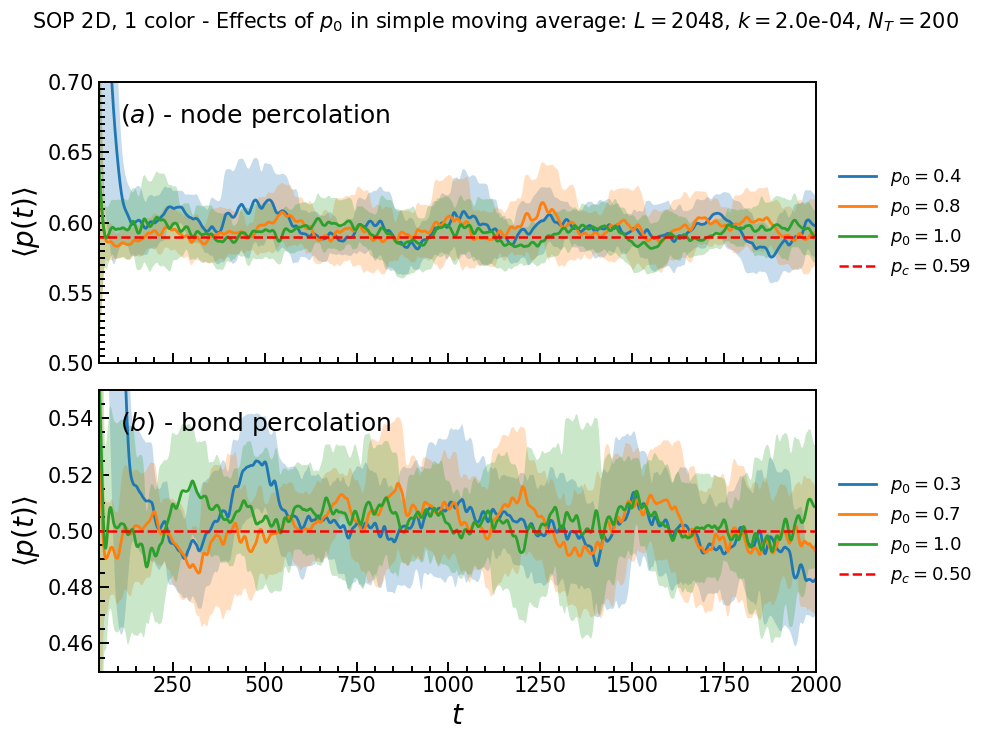

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MultipleLocator

# ---------- janela deslizante ----------
def rolling_mean_std(t, y, window: int):
    """
    Retorna (t_centrado, media, desvio_padrao) para uma janela deslizante de tamanho 'window'.
    A série resultante fica centrada na janela.
    """
    y = np.asarray(y, dtype=float)
    t = np.asarray(t, dtype=float)
    if window < 1 or window > len(y):
        raise ValueError("window fora do intervalo válido")

    c = np.cumsum(np.insert(y, 0, 0.0))
    c2 = np.cumsum(np.insert(y*y, 0, 0.0))

    mean = (c[window:] - c[:-window]) / window
    var = (c2[window:] - c2[:-window]) / window - mean**2
    std = np.sqrt(np.clip(var, 0, None))

    # centraliza no tempo (para janela par funciona como 'centered' padrão)
    t_center = t[(window-1)//2 : len(t) - window//2]
    return t_center, mean, std

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
fontsize_legend = 13
fontsize_labels = 20
fontsize_ticks = 15
thickness = 1.4

p_0_node = [0.4, 0.8, 1.0]
seeds_name_node = [13970049, 336794095 , 655361741] #lab

p_0_bond = [0.3, 0.7, 1.0]
seeds_name_bond = [570876, 1661938458, 2141247169] #lab

# p0 fixo
window = 100  # range da janela
rho = 1.0

fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(10, 7), sharex=True)

# --------- NODE ---------
for i, seed in enumerate(seeds_name_node):
    path = f"../Data/node_percolation/num_colors_{num_colors}/dim_{dim}/L_{L}/NT_constant/NT_{Nt}/k_{k:.1e}/rho_{rho:.4e}/data/"
    metas, df = load_bundle_old(path + f"P0_0.10_p0_{p_0_node[i]:.2f}_seed_{seeds_name_node[i]}.json")
    t, pt = df["t"], df["pt"]
    # média e desvio por janela
    tc, mu, sd = rolling_mean_std(t, pt, window)

    # (opcional) trace a série original fraquinha atrás:
    # axs[0].plot(t, pt, lw=1.0, alpha=0.25, color=colors[i])

    axs[0].plot(tc, mu, lw=2.0, color=colors[i], label=f'$p_0 = {p_0_node[i]}$')
    axs[0].fill_between(tc, mu - sd, mu + sd, alpha=0.25, color=colors[i], linewidth=0)

# --------- BOND ---------
for i, seed in enumerate(seeds_name_bond):
    path = f"../Data/bond_percolation/num_colors_{num_colors}/dim_{dim}/L_{L}/NT_constant/NT_{Nt}/k_{k:.1e}/rho_{rho:.4e}/data/"
    metas, df = load_bundle_old(path + f"P0_0.10_p0_{p_0_bond[i]:.2f}_seed_{seeds_name_bond[i]}.json")
    t, pt = df["t"], df["pt"]
    tc, mu, sd = rolling_mean_std(t, pt, window)

    # axs[1].plot(t, pt, lw=1.0, alpha=0.25, color=colors[i])  # opcional
    axs[1].plot(tc, mu, lw=2.0, color=colors[i], label=f'$p_0 = {p_0_bond[i]}$')
    axs[1].fill_between(tc, mu - sd, mu + sd, alpha=0.25, color=colors[i], linewidth=0)

axs[0].hlines(y=0.59, xmin=0, xmax=2000, linestyles="--", color='r', lw=1.8, label="$p_c = 0.59$")
axs[1].hlines(y=0.50, xmin=0, xmax=2000, linestyles="--", color='r', lw=1.8, label="$p_c = 0.50$")

# ---------- estética ----------
for ax in axs:
    ax.set_xlim([float(tc[0]), 2000])
    for spine in ax.spines.values():
        spine.set_linewidth(thickness)
    
    ax.tick_params(axis='both', labelsize=fontsize_ticks)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    
    ax.tick_params(axis='both', which='major', direction='in', labelsize=fontsize_ticks, length=7, width=thickness)
    ax.tick_params(axis='x',   which='minor', direction='in', length=4, width=thickness)
    ax.tick_params(axis='y',   which='minor', direction='in', length=4, width=thickness)

    ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5),
              framealpha=0.0, fontsize=fontsize_legend)
    ax.set_ylabel(r"$\langle p(t) \rangle$", fontsize=fontsize_labels)



axs[0].yaxis.set_major_locator(MultipleLocator(0.05))
axs[0].yaxis.set_minor_locator(MultipleLocator(0.005))

axs[0].text(0.03, 0.93, r"$(a)$ - node percolation", transform=axs[0].transAxes, ha="left", va="top", fontsize=18)
axs[1].text(0.03, 0.93, r"$(b)$ - bond percolation", transform=axs[1].transAxes, ha="left", va="top", fontsize=18)

axs[0].set_ylim([0.5,0.7])
axs[1].set_ylim([0.45,0.55])

axs[1].yaxis.set_major_locator(MultipleLocator(0.02))
axs[1].yaxis.set_minor_locator(MultipleLocator(0.005))


axs[1].set_xlabel("$t$", fontsize=fontsize_labels)

plt.subplots_adjust(hspace=0.15)
fig.tight_layout(rect=[0, 0, 1, 0.98])
fig.suptitle(f"SOP 2D, 1 color - Effects of $p_0$ in simple moving average: $L = {L}$, $k = ${k:.1e}, $N_T = {Nt}$", fontsize=15, y=1.05)
#plt.savefig(savepath_TS_1_color + "/rolling_mean_pt_2D_1color.pdf")
plt.show()

In [ ]:
# Create data with a lot of samples
L = 2048
k = 2.0e-04
Nt = 200
dim = 2
rho = 1.0
num_colors = 1
p_0_node = [0.4, 0.8, 1.0]
p_0_bond = [0.3, 0.7, 1.0]
type_perc = ["bond", "node"]
for type in type_perc:
    p0 = p_0_bond if type=='bond' else p_0_node
    compute_means_for_folder_new(type, num_colors,dim, L, Nt, k, 1.0, p0)

[ok] p0=0.30: 1000 arquivos agregados
[ok] p0=0.70: 1000 arquivos agregados
[ok] p0=1.00: 1000 arquivos agregados
[salvo] ../Data/bond_percolation/num_colors_1/dim_2/L_2048/NT_constant/NT_200/k_2.0e-04/rho_1.0000e+00/properties_mean_bundle.json
[ok] p0=0.40: 1000 arquivos agregados
[ok] p0=0.80: 1000 arquivos agregados
[ok] p0=1.00: 1000 arquivos agregados
[salvo] ../Data/node_percolation/num_colors_1/dim_2/L_2048/NT_constant/NT_200/k_2.0e-04/rho_1.0000e+00/properties_mean_bundle.json


In [12]:
path = f"../Data/node_percolation/num_colors_{num_colors}/dim_{dim}/L_{L}/NT_constant/NT_{Nt}/k_{k:.1e}/rho_{rho:.4e}/properties_mean_bundle.json"
a, b = load_bundle(path)
for keys in b[0.4][1]:
    print(keys)

time
pt_mean
pt_sem
n_seeds_pt
nt_mean
nt_sem
n_seeds_nt
time_percolation_mean
time_percolation_sem
n_seeds_time_perc
M_size_mean
M_size_sem
n_seeds_M_size


In [13]:
def load_means_bundle(type_perc, num_colors, dim, L, NT, k, rho):
    """
    Lê ../Data/<type>_percolation/.../properties_mean_bundle.json
    Retorna:
      P: {p0: {"t_grid": np.array, "mean": np.array, "sem": np.array}}
      C: {p0: {"files_used": int, "seeds": list[int]}}
    Assume ordem = 1 (num_colors=1). Se houver várias 'orders', pegue a desejada.
    """
    base_dir = "../Data"
    out_dir = os.path.join(
        base_dir,
        f"{type_perc}_percolation",
        f"num_colors_{num_colors}",
        f"dim_{dim}",
        f"L_{L}",
        "NT_constant",
        f"NT_{NT}",
        f"k_{k:.1e}",
        f"rho_{rho:.4e}",
    )
    bundle_path = os.path.join(out_dir, "properties_mean_bundle.json")
    if not os.path.isfile(bundle_path):
        raise FileNotFoundError(f"Bundle não encontrado: {bundle_path}\n(Gere com compute_means_for_folder_new)")

    with open(bundle_path, "r", encoding="utf-8") as f:
        bundle = json.load(f)

    # monta dicionários por p0
    P, C = {}, {}
    for grp in bundle.get("p0_groups", []):
        p0 = float(grp.get("p0_value"))
        num_seeds = int(grp.get("num_seeds", 0))
        seeds = grp.get("seeds", [])

        # pega a ordem 1 (para 1 cor). Ajuste aqui se quiser outra ordem.
        orders = grp.get("orders", [])
        o1 = next((o for o in orders if int(o.get("order_percolation", -1)) == 1), None)
        if not o1:
            continue
        d = o1.get("data", {})
        # campos do nosso bundle
        t_grid = np.asarray(d.get("time", []), dtype=float)
        mean   = np.asarray(d.get("pt_mean", []), dtype=float)
        sem    = np.asarray(d.get("pt_sem", []), dtype=float)

        P[p0] = {"t_grid": t_grid, "mean": mean, "sem": sem}
        C[p0] = {"files_used": num_seeds, "seeds": seeds}

    return P, C

## PROPERTIES WITH A LOT OF SAMPLES

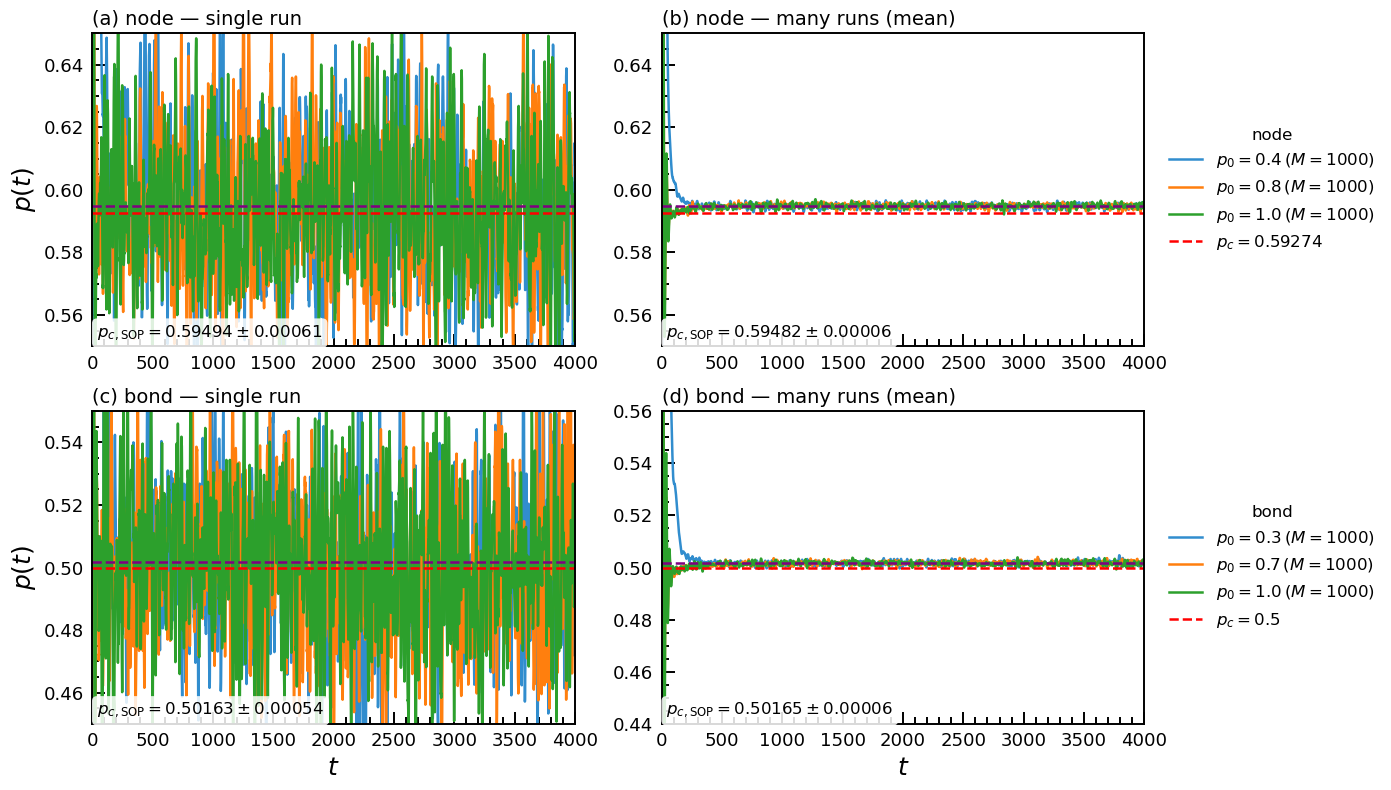

O número de amostras afeta de forma muito sútil o p_médio


In [15]:
# ----- params -----
L = 2048; NT = 200; k = 2.0e-04
num_colors = 1; rho = 1.0; dim = 2; burn = 300
p0_node = [0.4, 0.8, 1.0]
p0_bond = [0.3, 0.7, 1.0]
seeds_node = [13970049, 336794095 , 655361741]
seeds_bond = [570876, 1661938458, 2141247169]
pc_node, pc_bond = 0.59274, 0.50

# ----- estilo -----
colors = ["#318dce", "#ff7f0e", "#2ca02c", "#d62728"]
fontsize_ticks = 13; fontsize_legend = 12; fontsize_labels = 18; thickness = 1.4
tail_color = "purple"
legend_box = dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85, linewidth=0)

def _max_t(stats_by_p0):
    vals = [np.max(d["t_grid"]) for d in stats_by_p0.values() if d["t_grid"].size]
    return float(np.max(vals)) if vals else 4000.0

# ===== carregar os bundles de médias =====
p_node, C_node = load_means_bundle("node", num_colors, dim, L, NT, k, rho)
p_bond, C_bond = load_means_bundle("bond", num_colors, dim, L, NT, k, rho)

fig, axs = plt.subplots(2, 2, figsize=(14, 8), sharex=False)

# ================= Row 1: NODE =================
# (0,0) node — single run  >>> usa df["t"], df["pt"]
ax = axs[0,0]
tails = []
for i, (p0, seed) in enumerate(zip(p0_node, seeds_node)):
    base = f"../Data/node_percolation/num_colors_{num_colors}/dim_{dim}/L_{L}/NT_constant/NT_{NT}/k_{k:.1e}/rho_{rho:.4e}/data/"
    fname = f"P0_0.10_p0_{p0:.2f}_seed_{seed}.json"
    metas, df = load_bundle_old(os.path.join(base, fname))
    t, pt = df["t"].to_numpy(), df["pt"].to_numpy()
    ax.plot(t, pt, color=colors[i%len(colors)], lw=1.8, label="_nolegend_")
    if np.any(t >= burn): tails.append(np.mean(pt[t >= burn]))
# p_tail legend
if len(tails):
    mu = float(np.mean(tails))
    se = float(np.std(tails, ddof=1)/np.sqrt(len(tails))) if len(tails)>1 else 0.0
    h = ax.axhline(mu, 0, 1, color=tail_color, ls="--", lw=1.8,
                   label=rf'$p_{{c,\mathrm{{SOP}}}} = {mu:.5f} \pm {se:.5f}$')
    ax.text(0.01, 0.03, h.get_label(), transform=ax.transAxes,
            fontsize=fontsize_legend, bbox=legend_box)
ax.axhline(pc_node, 0, 1, color="r", ls="--", lw=1.8)
ax.set_title(r"(a) node — single run", loc="left", fontsize=14)
ax.set_ylabel(r"$p(t)$", fontsize=fontsize_labels)

# (0,1) node — many runs (mean)  >>> usa bundle de médias
ax = axs[0,1]
row_handles, row_labels = [], []
for i, p0 in enumerate(p0_node):
    d = p_node.get(p0, {"t_grid": np.array([]), "mean": np.array([]), "sem": np.array([])})
    files_used = C_node.get(p0, {}).get('files_used', 0)
    if d["t_grid"].size == 0: 
        continue
    ln, = ax.plot(d["t_grid"], d["mean"], color=colors[i%len(colors)], lw=1.8)
    row_handles.append(ln)
    row_labels.append(rf'$p_0={p0} \,(M={files_used})$')
# p_tail combinado (usando seu weighted_tail_from_sem)
tails_w = []
for p0 in p0_node:
    d = p_node.get(p0, {"t_grid": np.array([]), "mean": np.array([]), "sem": np.array([])})
    if d["t_grid"].size == 0: continue
    # espera-se uma função sua que aceite dict com chaves: t_grid/mean/sem
    stats_dict = {"t_grid": d["t_grid"], "mean": d["mean"], "sem": d["sem"]}
    mu, se, *_ = weighted_tail_from_sem(stats_dict, t_from=burn, corr_correct=True)
    tails_w.append((mu, se))
if tails_w:
    ws  = np.array([1/s**2 for m,s in tails_w if np.isfinite(s) and s>0])
    mus = np.array([m       for m,s in tails_w if np.isfinite(s) and s>0])
    if ws.size:
        mu = float(np.sum(ws*mus)/np.sum(ws)); se = float(1/np.sqrt(np.sum(ws)))
        h = ax.axhline(mu, 0, 1, color=tail_color, ls="--", lw=1.8,
                       label=rf'$p_{{c,\mathrm{{SOP}}}} = {mu:.5f} \pm {se:.5f}$')
        ax.text(0.01, 0.03, h.get_label(), transform=ax.transAxes,
                fontsize=fontsize_legend, bbox=legend_box)

pc_line = ax.axhline(pc_node, 0, 1, color="r", ls="--", lw=1.8, label=rf"$p_c = {pc_node}$")
row_handles.append(pc_line); row_labels.append(rf"$p_c = {pc_node}$")
ax.set_title(r"(b) node — many runs (mean)", loc="left", fontsize=14)
ax.set_xlim(0,4000)
axs[0,1].legend(row_handles, row_labels, loc="center left",
                bbox_to_anchor=(1.02, 0.5), framealpha=0.0, fontsize=fontsize_legend).set_title("node", prop={'size': fontsize_legend})

# y-range comum da 1ª linha
for ax0 in axs[0,:]:
    ax0.set_ylim(0.55, 0.65)
    ax0.set_xlim(0, _max_t(p_node))

# ================= Row 2: BOND =================
# (1,0) bond — single run
ax = axs[1,0]
tails = []
for i, (p0, seed) in enumerate(zip(p0_bond, seeds_bond)):
    base = f"../Data/bond_percolation/num_colors_{num_colors}/dim_{dim}/L_{L}/NT_constant/NT_{NT}/k_{k:.1e}/rho_{rho:.4e}/data/"
    fname = f"P0_0.10_p0_{p0:.2f}_seed_{seed}.json"
    metas, df = load_bundle_old(os.path.join(base, fname))
    t, pt = df["t"].to_numpy(), df["pt"].to_numpy()
    ax.plot(t, pt, color=colors[i%len(colors)], lw=1.8, label="_nolegend_")
    if np.any(t>=burn): tails.append(np.mean(pt[t>=burn]))
if len(tails):
    mu = float(np.mean(tails))
    se = float(np.std(tails, ddof=1)/np.sqrt(len(tails))) if len(tails)>1 else 0.0
    h = ax.axhline(mu, 0, 1, color=tail_color, ls="--", lw=1.8,
                   label=rf'$p_{{c,\mathrm{{SOP}}}} = {mu:.5f} \pm {se:.5f}$')
    ax.text(0.01, 0.03, h.get_label(), transform=ax.transAxes,
            fontsize=fontsize_legend, bbox=legend_box)

ax.axhline(pc_bond, 0, 1, color="r", ls="--", lw=1.8)
ax.set_title(r"(c) bond — single run", loc="left", fontsize=14)
axs[1,0].set_ylabel(r"$p(t)$", fontsize=fontsize_labels)
ax.set_ylim(0.45, 0.55); ax.set_xlim(0, 4000)

# (1,1) bond — many runs (mean)
ax = axs[1,1]
row_handles, row_labels = [], []
for i, p0 in enumerate(p0_bond):
    d = p_bond.get(p0, {"t_grid": np.array([]), "mean": np.array([]), "sem": np.array([])})
    files_used = C_bond.get(p0, {}).get('files_used', 0)
    if d["t_grid"].size == 0: 
        continue
    ln, = ax.plot(d["t_grid"], d["mean"], color=colors[i%len(colors)], lw=1.8)
    row_handles.append(ln); row_labels.append(rf'$p_0={p0} \,(M={files_used})$')
# p_tail combinado
tails_w = []
for p0 in p0_bond:
    d = p_bond.get(p0, {"t_grid": np.array([]), "mean": np.array([]), "sem": np.array([])})
    if d["t_grid"].size == 0: continue
    stats_dict = {"t_grid": d["t_grid"], "mean": d["mean"], "sem": d["sem"]}
    mu, se, *_ = weighted_tail_from_sem(stats_dict, t_from=burn, corr_correct=True)
    tails_w.append((mu, se))
if tails_w:
    ws  = np.array([1/s**2 for m,s in tails_w if np.isfinite(s) and s>0])
    mus = np.array([m       for m,s in tails_w if np.isfinite(s) and s>0])
    if ws.size:
        mu = float(np.sum(ws*mus)/np.sum(ws)); se = float(1/np.sqrt(np.sum(ws)))
        h = ax.axhline(mu, 0, 1, color=tail_color, ls="--", lw=1.8,
                       label=rf'$p_{{c,\mathrm{{SOP}}}} = {mu:.5f} \pm {se:.5f}$')
        ax.text(0.01, 0.03, h.get_label(), transform=ax.transAxes,
                fontsize=fontsize_legend, bbox=legend_box)

pc_line = ax.axhline(pc_bond, 0, 1, color="r", ls="--", lw=1.8, label=rf"$p_c = {pc_bond}$")
row_handles.append(pc_line); row_labels.append(rf"$p_c = {pc_bond}$")
ax.set_title(r"(d) bond — many runs (mean)", loc="left", fontsize=14)
axs[1,0].set_ylabel(r"$p(t)$", fontsize=fontsize_labels)
ax.set_ylim(0.44, 0.56)

if row_handles:
    leg = axs[1,1].legend(row_handles, row_labels,
                          loc="center left", bbox_to_anchor=(1.02, 0.5),
                          framealpha=0.0, fontsize=fontsize_legend)
    leg.set_title("bond", prop={'size': fontsize_legend})
else:
    print("[warn] legend(bond): no handles")
# ----- acabamento comum -----
for ax in axs.ravel():
    for s in ax.spines.values(): s.set_linewidth(thickness)
    ax.tick_params(axis='both', labelsize=fontsize_ticks)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_major_locator(MultipleLocator(0.02))
    ax.yaxis.set_minor_locator(MultipleLocator(0.005))
    ax.tick_params(axis='both', which='major', direction='in', length=9, width=thickness, pad=6)
    ax.tick_params(axis='x', which='minor', direction='in', length=5, width=thickness)
    ax.tick_params(axis='y', which='minor', direction='in', length=5, width=thickness)
    ax.set_xlim(0,4000)

axs[1,0].set_xlabel("$t$", fontsize=fontsize_labels)
axs[1,1].set_xlabel("$t$", fontsize=fontsize_labels)
plt.subplots_adjust(wspace=0.35, hspace=0.35, right=0.82)
fig.tight_layout()
plt.show()

print("O número de amostras afeta de forma muito sútil o p_médio")

## 2 COLORS

In [17]:
c = 0.1
L = 1024
print(f'Nt = {c*L**2}')
print(f'k = {0.2/L**2:.1e}')

Nt = 104857.6
k = 1.9e-07
